## Import libraries and data loader

In [102]:
import pandas as pd 
import numpy as np

In [103]:
kp_fish_path = pd.read_csv('../dataset/gbif/gbif_katsuwonus_pelamis.csv')
pa_fish_path = pd.read_csv('../dataset/gbif/gbif_pampus_argenteus.csv')
sc_fish_path = pd.read_csv('../dataset/gbif/gbif_scomberomorus_commerson.csv')
ta_fish_path = pd.read_csv('../dataset/gbif/gbif_thunnus_albacares.csv')
tl_fish_path = pd.read_csv('../dataset/gbif/gbif_trichiurus_lepturus.csv')

In [104]:
# Read and concat to get gbif_data
gbif_data = pd.concat([kp_fish_path, pa_fish_path, sc_fish_path, ta_fish_path, tl_fish_path], ignore_index=True)

In [105]:
print(gbif_data.columns.tolist())

['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'taxonRank', 'taxonomicStatus', 'iucnRedListCategory', 'dateIdentified', 'decimalLatitude', 'decimalLongitude', 'continent', 'stateProvince', 'gadm', 'year', 'month', 'day', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'issues', 'modified', 'lastInterpreted', 'references', 'license', 'isSequenced', 'identifiers', 'media', 'facts', 'relations', 'isInCluster', 'datasetName', 'recordedBy', 'identifiedBy', 'dnaSequenceID', 'geodeticDatum', 'countryCode', 'recordedByIDs', 'identifiedByIDs', '

In [106]:
print(gbif_data.shape)

(1500, 180)


In [107]:
# filter columns
filtered_columns = ['scientificName',
                    'taxonKey',
                    'individualCount', # The number of individuals represented at the time of occurrence
                    'organismQuantity', # The number or enumeration value for the quantity of organisms
                    'organismQuantityType', # The type of quantity of organisms (e.g., mass, volume, etc.)
                    'sex', # the sex of the biological individual(s) represented in the occurrence
                    'lifeStage', # The life stage or developmental stage of the biological individual(s) represented in the occurrence
                    'occurrenceStatus', # Present for yes, absent for no, mostly present

                    ### Locations
                    'continent',
                    'countryCode',
                    'stateProvince',
                    'island',
                    'decimalLatitude',
                    'decimalLongitude',
                    'elevation',
                    'elevationAccuracy',

                    ## Date
                    'eventDate',
                    'year',
                    'month',
                    'day'
]
gbif_data_subset = gbif_data[filtered_columns]

In [108]:
# Save CSV file
# gbif_data_subset.to_csv('../dataset/gbif_five_species_cleaned.csv', index=False)

In [109]:
print(gbif_data_subset.head(5))

                        scientificName  taxonKey  individualCount  \
0  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
1  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
2  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
3  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   
4  Katsuwonus pelamis (Linnaeus, 1758)   2374191              NaN   

   organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
0               NaN                  NaN  NaN       NaN          PRESENT   
1               NaN                  NaN  NaN       NaN          PRESENT   
2               NaN                  NaN  NaN       NaN          PRESENT   
3               NaN                  NaN  NaN       NaN          PRESENT   
4               NaN                  NaN  NaN       NaN          PRESENT   

  continent countryCode stateProvince island  decimalLatitude  \
0      ASIA          TW        Taiwan    NaN        25.128225  

In [110]:
print(gbif_data_subset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scientificName        1500 non-null   object 
 1   taxonKey              1500 non-null   int64  
 2   individualCount       142 non-null    float64
 3   organismQuantity      227 non-null    float64
 4   organismQuantityType  227 non-null    object 
 5   sex                   21 non-null     object 
 6   lifeStage             99 non-null     object 
 7   occurrenceStatus      1500 non-null   object 
 8   continent             951 non-null    object 
 9   countryCode           1491 non-null   object 
 10  stateProvince         896 non-null    object 
 11  island                26 non-null     object 
 12  decimalLatitude       1500 non-null   float64
 13  decimalLongitude      1500 non-null   float64
 14  elevation             24 non-null     float64
 15  elevationAccuracy    

In [111]:
print(gbif_data_subset.describe())

           taxonKey  individualCount  organismQuantity  decimalLatitude  \
count  1.500000e+03       142.000000        227.000000      1500.000000   
mean   2.407292e+06        82.852113        389.114537        10.635378   
std    4.388988e+05       839.732885       1207.986721        24.062091   
min    2.374013e+06         0.000000          0.000000       -44.966667   
25%    2.374191e+06         1.000000          2.000000       -10.266008   
50%    2.374255e+06         1.000000         23.000000        18.991667   
75%    2.389407e+06         1.000000        241.500000        32.831956   
max    1.043311e+07     10000.000000       9230.000000        57.051006   

       decimalLongitude  elevation  elevationAccuracy         year  \
count       1500.000000   24.00000          24.000000  1500.000000   
mean          27.670601   91.36250          34.791667  2021.346667   
std          100.922479  127.65128          61.634956     4.509698   
min         -179.756562    0.00000          

In [112]:
# Unique value of categorical columns
categorical_columns = ['scientificName','taxonKey', 'organismQuantityType', 'sex', 'lifeStage', 'occurrenceStatus', 'continent', 'countryCode', 'stateProvince', 'island']
for col in categorical_columns:
    unique_values = gbif_data_subset[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'scientificName': ['Katsuwonus pelamis (Linnaeus, 1758)' 'BOLD:AAA5421'
 'Pampus argenteus (Euphrasen, 1788)' 'Pampus cinereus (Bloch, 1795)'
 'Scomberomorus commerson (Lacepède, 1800)' 'BOLD:AAB5512'
 'Thunnus albacares (Bonnaterre, 1788)'
 'Trichiurus lepturus Linnaeus, 1758'
 'Trichiurus japonicus Temminck & Schlegel, 1844']
Unique values in column 'taxonKey': [ 2374191  9877823  2397682  2397674  2374255 10433110  2374013  2389407
  2389414]
Unique values in column 'organismQuantityType': [nan 'DNA Sequence reads' 'reads' 'KILOGRAMO' 'número-de-indivíduos'
 'Peso en kg' 'individuos 10m2' 'individuals']
Unique values in column 'sex': [nan 'Indeterminate' 'Female' 'Male']
Unique values in column 'lifeStage': [nan 'Unknown' 'Adult' 'Egg' 'Juvenile' 'Larva']
Unique values in column 'occurrenceStatus': ['PRESENT' 'ABSENT']
Unique values in column 'continent': ['ASIA' 'AFRICA' nan 'SOUTH_AMERICA' 'OCEANIA' 'NORTH_AMERICA' 'EUROPE']
Unique values in column 'country

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Thunnus albacares (Bonnaterre, 1788)'),
  Text(1, 0, 'Pampus argenteus (Euphrasen, 1788)'),
  Text(2, 0, 'Scomberomorus commerson (Lacepède, 1800)'),
  Text(3, 0, 'Katsuwonus pelamis (Linnaeus, 1758)'),
  Text(4, 0, 'Trichiurus lepturus Linnaeus, 1758'),
  Text(5, 0, 'Trichiurus japonicus Temminck & Schlegel, 1844'),
  Text(6, 0, 'BOLD:AAA5421'),
  Text(7, 0, 'Pampus cinereus (Bloch, 1795)'),
  Text(8, 0, 'BOLD:AAB5512')])

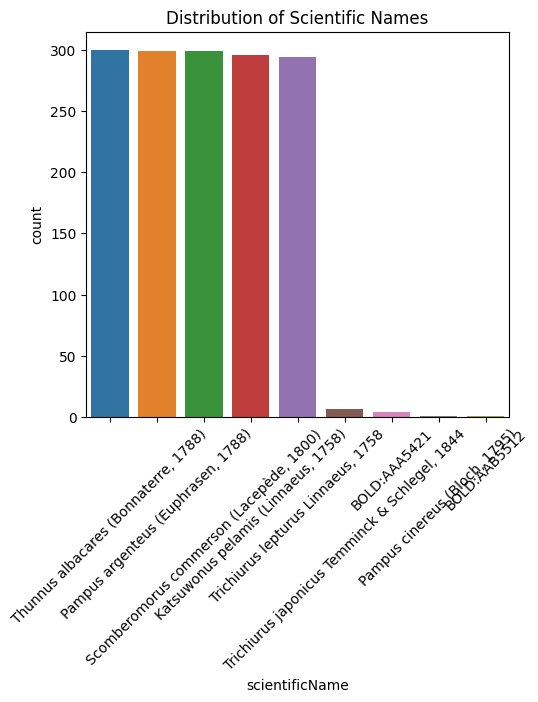

In [113]:
# Plot distribution of scientificName, occurrenceStatus
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='scientificName', order=gbif_data_subset['scientificName'].value_counts().index)
plt.title('Distribution of Scientific Names')
plt.xticks(rotation=45)

(array([0, 1]), [Text(0, 0, 'PRESENT'), Text(1, 0, 'ABSENT')])

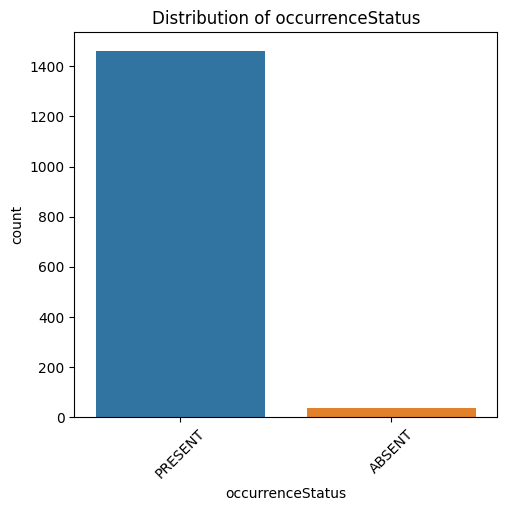

In [114]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='occurrenceStatus', order=gbif_data_subset['occurrenceStatus'].value_counts().index)
plt.title('Distribution of occurrenceStatus')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Adult'),
  Text(1, 0, 'Juvenile'),
  Text(2, 0, 'Egg'),
  Text(3, 0, 'Unknown'),
  Text(4, 0, 'Larva')])

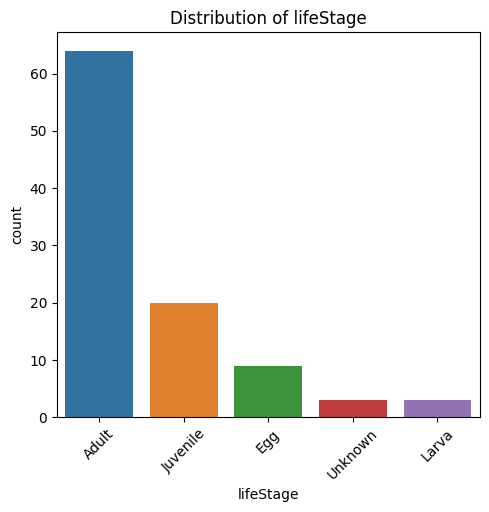

In [115]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='lifeStage', order=gbif_data_subset['lifeStage'].value_counts().index)
plt.title('Distribution of lifeStage')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'ASIA'),
  Text(1, 0, 'NORTH_AMERICA'),
  Text(2, 0, 'OCEANIA'),
  Text(3, 0, 'AFRICA'),
  Text(4, 0, 'SOUTH_AMERICA'),
  Text(5, 0, 'EUROPE')])

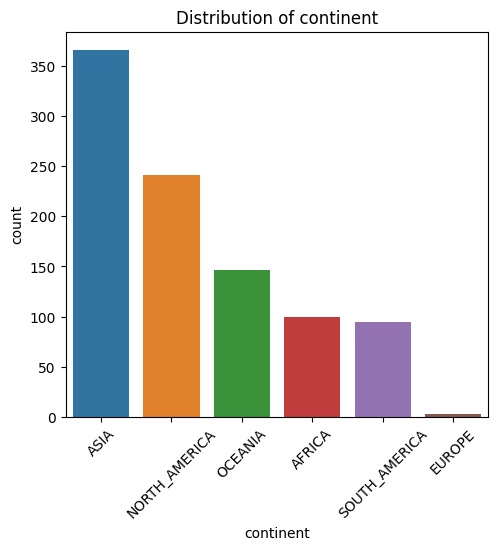

In [116]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='continent', order=gbif_data_subset['continent'].value_counts().index)
plt.title('Distribution of continent')
plt.xticks(rotation=45)

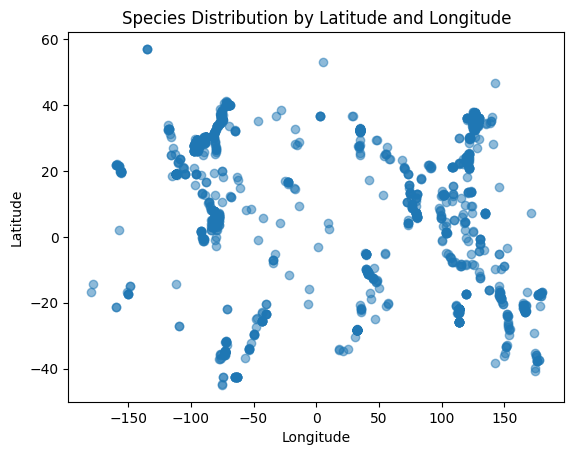

In [117]:
# distribution by lat long
import matplotlib.pyplot as plt
plt.scatter(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution by Latitude and Longitude')
plt.show()

In [119]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)


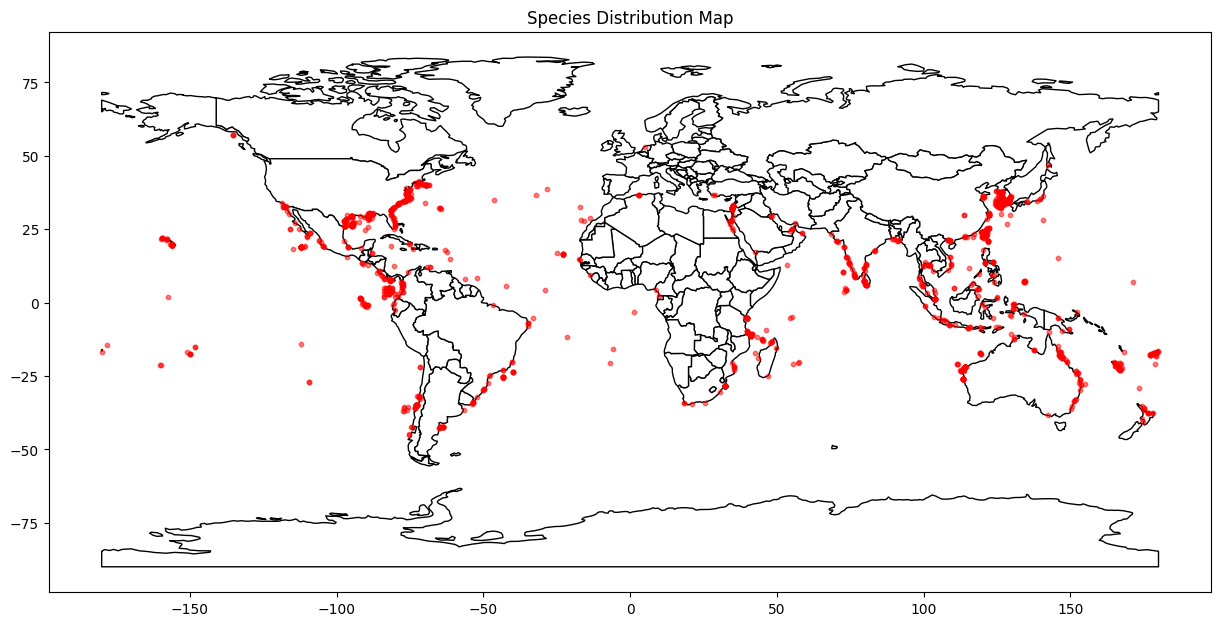

In [120]:
# Add map visualization
import geopandas as gpd
from shapely.geometry import Point 
geometry = [Point(xy) for xy in zip(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'])]
geo_df = gpd.GeoDataFrame(gbif_data_subset, geometry=geometry)
world = gpd.read_file(url)
ax = world.plot(figsize=(15, 10), color='white', edgecolor='black')
geo_df.plot(ax=ax, markersize=10, color='red', alpha=0.5)
plt.title('Species Distribution Map')
plt.show()